Algoritmos Metaheuristicos  
Tarea 6 - Organizacion de Horarios (UCTP)  
Autor: Ing. Daniel Eduardo González Alvarado  
Profesor: Dr. Marco Aceves

# Bin Packing Problem

Se busca minimizar la funcion:  

$z(y)=\sum_{i=1}^{n}(y_i)$  

La cual representa el numero de contenedores utilizados y esta sujeta a:  


$\left[ \sum_{j=1}^{n} p_j x_{ij} \right] \leq c_i y_i $
$\qquad i \in \mathbb{N} = \{1,2,\dots,n\}$

$\sum_{i=1}^{n} x_{ij} = 1 $
$\qquad j \in \mathbb{N}$


Donde:

$
y_i = \begin{cases}
1 & \text{Si se usa el contenedor } i \\
0 & \text{Cualquier otro caso}
\end{cases}
$

$
x_{ij} =\begin{cases}
1 & \text{Objeto } j \text{ se asigna al contenedor } i \\
0 & \text{Cualquier otro caso}
\end{cases}
$

Para este problema tenemos los siguientes contenedores nombrados de la A a la E y 7 paquetes de diferentes tamaños:

![Bin Packin Problem](\Reportes\Bin_Packing\rsc\img\des\Bin_packing.png)

Existen diferentes formas de organizar los paquetes en los contenedores por ejemplo:  

![Ejemplos](\Reportes\Bin_Packing\rsc\img\des\ejemplos.png)  

Podemos ver que la capacidad maxima de los contenedores es de 6, dato que nos sera util más adelante.

# Importar Librerias

In [24]:
import numpy as np
import random
import matplotlib.pyplot as plt

# Consideraciones Iniciales

In [2]:
# Capacidad de los contenedores
CAP = 6

# Contenedores disponibles
contenedores = ["A", "B", "C", "D", "E"]
n_contenedores = len(contenedores)

# Tamaños de los paquetes
paq = [2, 4, 3, 5, 3, 4, 1]
n_paquetes = len(paq)

print("Contenedores:", contenedores)
print("Capacidad por contenedor:", CAP)
print("Paquetes:", paq)

Contenedores: ['A', 'B', 'C', 'D', 'E']
Capacidad por contenedor: 6
Paquetes: [2, 4, 3, 5, 3, 4, 1]


# Evaluar Aptitud

In [ ]:
def eval_sol(solucion):
    # Carga en cada contenedor
    carga = [0] * n_contenedores
    
    for i, cont in enumerate(solucion):
        carga[cont] += paq[i]
    
    # Verificar Capacidad
    for c in carga:
        if c > CAP:
            return 1e-6, carga  # Penalización si se excede la capacidad
    
    # Contenedores usados
    usados = sum(1 for c in carga if c > 0)
    
    # Espacio desperdiciado
    desperdicio = usados * CAP - sum(paq)
    costo = usados + 0.1 * desperdicio
    fitness = 1.0 / (1.0 + costo)
    
    return fitness, carga


# Ant Colony

### Inicializar las Feromonas

In [ ]:

alpha = 1.0     # importancia de la feromona
beta = 2.0      # importancia de la heurística
rho = 0.5       # tasa de evaporación
Q = 1.0         # cantidad de feromona depositada


In [ ]:
def heuristica(paq_idx, cont_idx, carga_actual):
    size = paq[paq_idx]
    carga_cont = carga_actual[cont_idx]
    
    if carga_cont + size > CAP:
        return 1e-6
    
    # Capacidad restante
    restante = CAP - (carga_cont + size)
    
    return 1.0 / (1.0 + restante)


### Camino

In [ ]:
def construir_solucion(tau, alpha, beta):
    carga = [0] * n_contenedores
    solucion = [None] * n_paquetes
    
    for j in range(n_paquetes): 
        atractividades = []
        for k in range(n_contenedores):
            eta = heuristica(j, k, carga)
            t = tau[j, k] ** alpha
            a = t * (eta ** beta)
            atractividades.append(a)
        
        atractividades = np.array(atractividades)
        probs = atractividades / atractividades.sum()

        cont_elegido = np.random.choice(range(n_contenedores), p=probs)

        solucion[j] = cont_elegido
        carga[cont_elegido] += paq[j]
    
    return solucion

# Metricas

In [ ]:
def metricas():
    tau = np.ones((n_paquetes, n_contenedores))
    mejor_solucion_global = None
    mejor_fitness_global = -1
    mejor_carga_global = None
    
    # Historial
    hist_mejor = []
    hist_prom = []
    
    return tau, mejor_solucion_global, mejor_fitness_global, mejor_carga_global, hist_mejor, hist_prom

# Algoritmo Principal

In [ ]:
def ant_colony(n_hormigas, n_iteraciones):
    # Inicializamos métricas y feromonas
    (tau,
     mejor_solucion_global,
     mejor_fitness_global,
     mejor_carga_global,
     hist_mejor,
     hist_prom) = metricas()

    for it in range(n_iteraciones):
        soluciones = []
        fitnesses = []
        
        for _ in range(n_hormigas):
            sol = construir_solucion(tau, alpha, beta)
            fit, carga = eval_sol(sol)
            soluciones.append((sol, carga))
            fitnesses.append(fit)
        
        fitnesses = np.array(fitnesses)
        
        # Mejor hormiga
        idx_best = int(np.argmax(fitnesses))
        sol_best, carga_best = soluciones[idx_best]
        fit_best = float(fitnesses[idx_best])
        
        # Promedio
        fit_prom = float(fitnesses.mean())
        
        # Guardar métricas
        hist_mejor.append(fit_best)
        hist_prom.append(fit_prom)
        
        # Actualizar mejor global
        if fit_best > mejor_fitness_global:
            mejor_fitness_global = fit_best
            mejor_solucion_global = sol_best
            mejor_carga_global = carga_best
        
        # Evaporación
        tau = (1 - rho) * tau
        
        # Depósito de feromona
        for j, cont in enumerate(sol_best):
            tau[j, cont] += Q * fit_best
        
        # Monitoreo
        if (it + 1) % 10 == 0 or it == 0:
            print(
                f"Iteración {it+1} | "
                f"Mejor fitness iteración: {fit_best:.4f} | "
                f"Promedio: {fit_prom:.4f} | "
                f"Mejor global: {mejor_fitness_global:.4f}"
            )
    
    return mejor_solucion_global, mejor_fitness_global, mejor_carga_global, tau, hist_mejor, hist_prom

# Ejecucion

In [23]:
(mejor_sol,
 mejor_fit,
 mejor_carga,
 tau_final,
 hist_mejor,
 hist_prom) = ant_colony(n_hormigas=20, n_iteraciones=50)

print("\n=== MEJOR SOLUCIÓN ENCONTRADA ===")
print("Asignación (paquete -> contenedor):")
for i, cont in enumerate(mejor_sol):
    print(f"Paquete {i} (size={paq[i]}) -> Contenedor {contenedores[cont]}")

print("\nCargas por contenedor:")
for i, c in enumerate(mejor_carga):
    print(f"{contenedores[i]}: carga = {c} / {CAP}")

print("\nMejor fitness global:", mejor_fit)


Iteración 1 | Mejor fitness iteración: 0.1923 | Promedio: 0.1833 | Mejor global: 0.1923
Iteración 10 | Mejor fitness iteración: 0.1923 | Promedio: 0.1923 | Mejor global: 0.1923
Iteración 20 | Mejor fitness iteración: 0.1923 | Promedio: 0.1923 | Mejor global: 0.1923
Iteración 30 | Mejor fitness iteración: 0.1923 | Promedio: 0.1923 | Mejor global: 0.1923
Iteración 40 | Mejor fitness iteración: 0.1923 | Promedio: 0.1923 | Mejor global: 0.1923
Iteración 50 | Mejor fitness iteración: 0.1923 | Promedio: 0.1923 | Mejor global: 0.1923

=== MEJOR SOLUCIÓN ENCONTRADA ===
Asignación (paquete -> contenedor):
Paquete 0 (size=2) -> Contenedor D
Paquete 1 (size=4) -> Contenedor D
Paquete 2 (size=3) -> Contenedor C
Paquete 3 (size=5) -> Contenedor A
Paquete 4 (size=3) -> Contenedor C
Paquete 5 (size=4) -> Contenedor E
Paquete 6 (size=1) -> Contenedor A

Cargas por contenedor:
A: carga = 6 / 6
B: carga = 0 / 6
C: carga = 6 / 6
D: carga = 6 / 6
E: carga = 4 / 6

Mejor fitness global: 0.1923076923076923


# Graficas

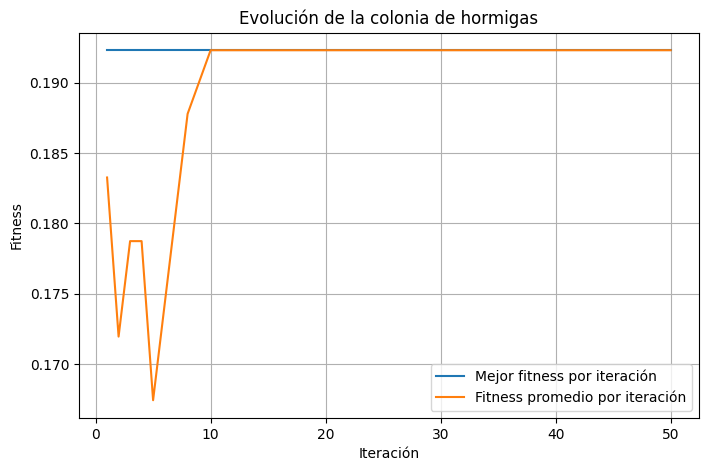

In [25]:
iteraciones = range(1, len(hist_mejor) + 1)

plt.figure(figsize=(8, 5))
plt.plot(iteraciones, hist_mejor, label="Mejor fitness por iteración")
plt.plot(iteraciones, hist_prom, label="Fitness promedio por iteración")
plt.xlabel("Iteración")
plt.ylabel("Fitness")
plt.title("Evolución de la colonia de hormigas")
plt.legend()
plt.grid(True)
plt.show()


# Prueba Extra

In [28]:
# Capacidad de los contenedores
CAP = 6

# Contenedores disponibles
contenedores = ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L", "M", 
                "N", "O", "P", "Q", "R", "S", "T", "U", "V", "W", "X", "Y", "Z"]
n_contenedores = len(contenedores)

# Tamaños de los paquetes
random.seed(16)
paq = [random.randint(1, 6) for _ in range(20)]
n_paquetes = len(paq)

print("Contenedores:", contenedores)
print("Capacidad por contenedor:", CAP)
print("Paquetes:", paq)

Contenedores: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Capacidad por contenedor: 6
Paquetes: [3, 4, 4, 3, 4, 2, 4, 1, 4, 6, 6, 3, 2, 6, 2, 1, 3, 3, 3, 6]


In [34]:
(mejor_sol,
 mejor_fit,
 mejor_carga,
 tau_final,
 hist_mejor,
 hist_prom) = ant_colony(n_hormigas=2, n_iteraciones=50)

print("\n=== MEJOR SOLUCIÓN ENCONTRADA ===")
print("Asignación (paquete -> contenedor):")
for i, cont in enumerate(mejor_sol):
    print(f"Paquete {i} (size={paq[i]}) -> Contenedor {contenedores[cont]}")

print("\nCargas por contenedor:")
for i, c in enumerate(mejor_carga):
    print(f"{contenedores[i]}: carga = {c} / {CAP}")

print("\nMejor fitness global:", mejor_fit)

Iteración 1 | Mejor fitness iteración: 0.0676 | Promedio: 0.0676 | Mejor global: 0.0676
Iteración 10 | Mejor fitness iteración: 0.0610 | Promedio: 0.0583 | Mejor global: 0.0758
Iteración 20 | Mejor fitness iteración: 0.0610 | Promedio: 0.0610 | Mejor global: 0.0758
Iteración 30 | Mejor fitness iteración: 0.0610 | Promedio: 0.0610 | Mejor global: 0.0758
Iteración 40 | Mejor fitness iteración: 0.0610 | Promedio: 0.0610 | Mejor global: 0.0758
Iteración 50 | Mejor fitness iteración: 0.0610 | Promedio: 0.0610 | Mejor global: 0.0758

=== MEJOR SOLUCIÓN ENCONTRADA ===
Asignación (paquete -> contenedor):
Paquete 0 (size=3) -> Contenedor W
Paquete 1 (size=4) -> Contenedor Y
Paquete 2 (size=4) -> Contenedor U
Paquete 3 (size=3) -> Contenedor W
Paquete 4 (size=4) -> Contenedor C
Paquete 5 (size=2) -> Contenedor Y
Paquete 6 (size=4) -> Contenedor D
Paquete 7 (size=1) -> Contenedor D
Paquete 8 (size=4) -> Contenedor S
Paquete 9 (size=6) -> Contenedor J
Paquete 10 (size=6) -> Contenedor H
Paquete 11

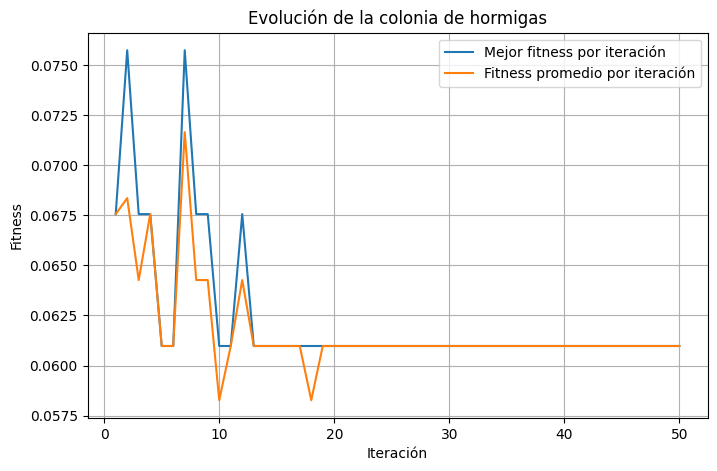

In [35]:
iteraciones = range(1, len(hist_mejor) + 1)

plt.figure(figsize=(8, 5))
plt.plot(iteraciones, hist_mejor, label="Mejor fitness por iteración")
plt.plot(iteraciones, hist_prom, label="Fitness promedio por iteración")
plt.xlabel("Iteración")
plt.ylabel("Fitness")
plt.title("Evolución de la colonia de hormigas")
plt.legend()
plt.grid(True)
plt.show()

In [36]:
(mejor_sol,
 mejor_fit,
 mejor_carga,
 tau_final,
 hist_mejor,
 hist_prom) = ant_colony(n_hormigas=5, n_iteraciones=50)

print("\n=== MEJOR SOLUCIÓN ENCONTRADA ===")
print("Asignación (paquete -> contenedor):")
for i, cont in enumerate(mejor_sol):
    print(f"Paquete {i} (size={paq[i]}) -> Contenedor {contenedores[cont]}")

print("\nCargas por contenedor:")
for i, c in enumerate(mejor_carga):
    print(f"{contenedores[i]}: carga = {c} / {CAP}")

print("\nMejor fitness global:", mejor_fit)

Iteración 1 | Mejor fitness iteración: 0.0676 | Promedio: 0.0625 | Mejor global: 0.0676
Iteración 10 | Mejor fitness iteración: 0.0758 | Promedio: 0.0618 | Mejor global: 0.0758
Iteración 20 | Mejor fitness iteración: 0.0758 | Promedio: 0.0758 | Mejor global: 0.0758
Iteración 30 | Mejor fitness iteración: 0.0758 | Promedio: 0.0758 | Mejor global: 0.0758
Iteración 40 | Mejor fitness iteración: 0.0758 | Promedio: 0.0758 | Mejor global: 0.0758
Iteración 50 | Mejor fitness iteración: 0.0758 | Promedio: 0.0758 | Mejor global: 0.0758

=== MEJOR SOLUCIÓN ENCONTRADA ===
Asignación (paquete -> contenedor):
Paquete 0 (size=3) -> Contenedor G
Paquete 1 (size=4) -> Contenedor M
Paquete 2 (size=4) -> Contenedor E
Paquete 3 (size=3) -> Contenedor G
Paquete 4 (size=4) -> Contenedor H
Paquete 5 (size=2) -> Contenedor H
Paquete 6 (size=4) -> Contenedor L
Paquete 7 (size=1) -> Contenedor J
Paquete 8 (size=4) -> Contenedor J
Paquete 9 (size=6) -> Contenedor B
Paquete 10 (size=6) -> Contenedor P
Paquete 11

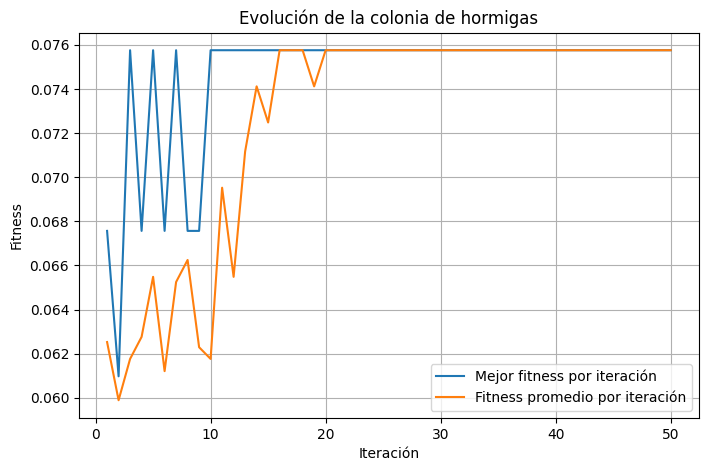

In [37]:
iteraciones = range(1, len(hist_mejor) + 1)

plt.figure(figsize=(8, 5))
plt.plot(iteraciones, hist_mejor, label="Mejor fitness por iteración")
plt.plot(iteraciones, hist_prom, label="Fitness promedio por iteración")
plt.xlabel("Iteración")
plt.ylabel("Fitness")
plt.title("Evolución de la colonia de hormigas")
plt.legend()
plt.grid(True)
plt.show()

In [38]:
(mejor_sol,
 mejor_fit,
 mejor_carga,
 tau_final,
 hist_mejor,
 hist_prom) = ant_colony(n_hormigas=10, n_iteraciones=50)

print("\n=== MEJOR SOLUCIÓN ENCONTRADA ===")
print("Asignación (paquete -> contenedor):")
for i, cont in enumerate(mejor_sol):
    print(f"Paquete {i} (size={paq[i]}) -> Contenedor {contenedores[cont]}")

print("\nCargas por contenedor:")
for i, c in enumerate(mejor_carga):
    print(f"{contenedores[i]}: carga = {c} / {CAP}")

print("\nMejor fitness global:", mejor_fit)

Iteración 1 | Mejor fitness iteración: 0.0758 | Promedio: 0.0635 | Mejor global: 0.0758
Iteración 10 | Mejor fitness iteración: 0.0676 | Promedio: 0.0650 | Mejor global: 0.0758
Iteración 20 | Mejor fitness iteración: 0.0758 | Promedio: 0.0749 | Mejor global: 0.0758
Iteración 30 | Mejor fitness iteración: 0.0758 | Promedio: 0.0758 | Mejor global: 0.0758
Iteración 40 | Mejor fitness iteración: 0.0758 | Promedio: 0.0758 | Mejor global: 0.0758
Iteración 50 | Mejor fitness iteración: 0.0758 | Promedio: 0.0758 | Mejor global: 0.0758

=== MEJOR SOLUCIÓN ENCONTRADA ===
Asignación (paquete -> contenedor):
Paquete 0 (size=3) -> Contenedor N
Paquete 1 (size=4) -> Contenedor P
Paquete 2 (size=4) -> Contenedor V
Paquete 3 (size=3) -> Contenedor N
Paquete 4 (size=4) -> Contenedor K
Paquete 5 (size=2) -> Contenedor Z
Paquete 6 (size=4) -> Contenedor Z
Paquete 7 (size=1) -> Contenedor P
Paquete 8 (size=4) -> Contenedor E
Paquete 9 (size=6) -> Contenedor M
Paquete 10 (size=6) -> Contenedor F
Paquete 11

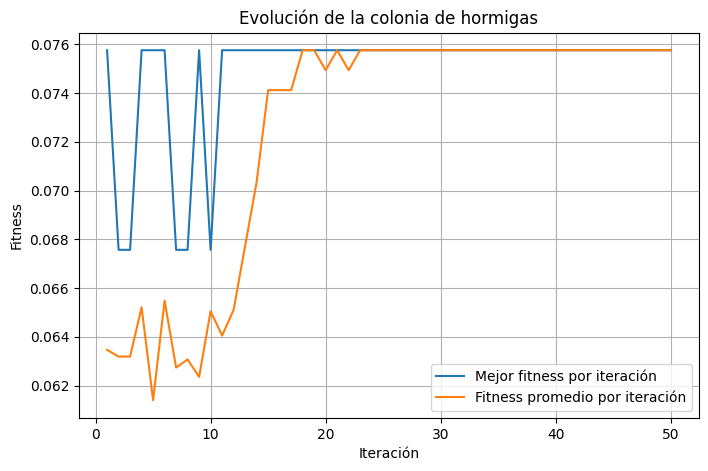

In [39]:
iteraciones = range(1, len(hist_mejor) + 1)

plt.figure(figsize=(8, 5))
plt.plot(iteraciones, hist_mejor, label="Mejor fitness por iteración")
plt.plot(iteraciones, hist_prom, label="Fitness promedio por iteración")
plt.xlabel("Iteración")
plt.ylabel("Fitness")
plt.title("Evolución de la colonia de hormigas")
plt.legend()
plt.grid(True)
plt.show()